<a href="https://colab.research.google.com/github/bhoomi162005-source/Monk9tech_VLSI_INTERSHIP_TASKS/blob/main/AVPTI_VLSI_INTERNSHIP_ASIC_LABS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from pathlib import Path
import subprocess
import sys
import shutil
import tempfile

os.environ["LOCALE_ARCHIVE"] = "/usr/lib/locale/locale-archive"

if "google.colab" in sys.modules:
    if shutil.which("nix-env") is None:
        with tempfile.TemporaryDirectory() as d:
            d = Path(d)
            installer_path = d / "nix"
            !curl --proto '=https' --tlsv1.2 -sSf -L https://install.determinate.systems/nix > {installer_path}
            with subprocess.Popen(
                [
                    "bash",
                    installer_path,
                    "install",
                    "--prefer-upstream-nix",
                    "--no-confirm",
                    "--extra-conf",
                    "extra-substituters = https://nix-cache.fossi-foundation.org\nextra-trusted-public-keys = nix-cache.fossi-foundation.org:3+K59iFwXqKsL7BNu6Guy0v+uTlwsxYQxjspXzqLYQs=\n",
                ],
                stdout=subprocess.PIPE,
                stderr=subprocess.STDOUT,
                encoding="utf8",
            ) as p:
                for line in p.stdout:
                    print(line, end="")
else:
    if shutil.which("nix-env") is None:
        raise RuntimeError("Nix is not installed!")

os.environ["PATH"] = f"/nix/var/nix/profiles/default/bin/:{os.getenv('PATH')}"

info: downloading installer
 INFO nix-installer v3.15.2
 INFO Step: Create directory `/nix`
 INFO Step: Provision Nix
 INFO Step: Create build users (UID 30001-30032) and group (GID 30000)
 INFO Step: Configure Nix
 INFO Step: Create directory `/etc/tmpfiles.d`
 INFO Step: Configure upstream Nix daemon service
 INFO Step: Remove directory `/nix/temp-install-dir`
 WARN SelfTest([ShellFailed { shell: Sh, command: "\"sh\" \"-lc\" \"exec nix build --option substitute false --option post-build-hook \\'\\' --no-link --expr \\'derivation { name = \\\"self-test-sh-1770626429366\\\"; system = \\\"x86_64-linux\\\"; builder = \\\"/bin/sh\\\"; args = [\\\"-c\\\" \\\"echo hello > \\\\$out\\\"]; }\\'\"", output: Output { status: ExitStatus(unix_wait_status(256)), stdout: "", stderr: "error:\n       … while calling the 'derivationStrict' builtin\n         at «nix-internal»/derivation-internal.nix:37:12:\n           36|\n           37|   strict = derivationStrict drvAttrs;\n             |            ^

In [2]:
import os
import subprocess
import IPython

librelane_version = "latest"  # @param {key:"LibreLane Version", type:"string"}

if librelane_version == "latest":
    librelane_version = "main"

pdk_root = "~/.ciel"  # @param {key:"PDK Root", type:"string"}

pdk_root = os.path.expanduser(pdk_root)

pdk = "sky130"  # @param {key:"PDK (without the variant)", type:"string"}

librelane_ipynb_path = os.path.join(os.getcwd(), "librelane_ipynb")

display(IPython.display.HTML("<h3>Downloading LibreLane…</a>"))


TESTING_LOCALLY = False
!rm -rf {librelane_ipynb_path}
!mkdir -p {librelane_ipynb_path}
if TESTING_LOCALLY:
    !ln -s {os.getcwd()} {librelane_ipynb_path}
else:
    !curl -L "https://github.com/librelane/librelane/tarball/{librelane_version}" | tar -xzC {librelane_ipynb_path} --strip-components 1

try:
    import tkinter
except ImportError:
    if "google.colab" in sys.modules:
        !sudo apt-get install python-tk

try:
    import tkinter
except ImportError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to import the <code>tkinter</code> library for Python, which is required to load PDK configuration values. Make sure <code>python3-tk</code> or equivalent is installed on your system.</a>'
        )
    )
    raise e from None


display(IPython.display.HTML("<h3>Downloading LibreLane's dependencies…</a>"))
try:
    with subprocess.Popen(
        [
            "nix",
            "profile",
            "install",
            ".#colab-env",
        ],
        cwd=librelane_ipynb_path,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        encoding="utf8",
    ) as p:
        for line in p.stdout:
            print(line, end="")
except subprocess.CalledProcessError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to install binary dependencies using Nix…</h3>'
        )
    )

display(IPython.display.HTML("<h3>Downloading Python dependencies using PIP…</a>"))
try:
    subprocess.check_call(
        ["pip3", "install", "."],
        cwd=librelane_ipynb_path,
    )
except subprocess.CalledProcessError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to install Python dependencies using PIP…</h3>'
        )
    )
    raise e from None

display(IPython.display.HTML("<h3>Downloading PDK…</a>"))
import ciel
from ciel.source import StaticWebDataSource

ciel.enable(
    ciel.get_ciel_home(pdk_root),
    pdk,
    open(
        os.path.join(librelane_ipynb_path, "librelane", "open_pdks_rev"),
        encoding="utf8",
    )
    .read()
    .strip(),
    data_source=StaticWebDataSource("https://fossi-foundation.github.io/ciel-releases"),
)

sys.path.insert(0, librelane_ipynb_path)
display(IPython.display.HTML("<h3>⭕️ Done.</a>"))

import logging

# Remove the stupid default colab logging handler
logging.getLogger().handlers.clear()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 9487k    0 9487k    0     0  7035k      0 --:--:--  0:00:01 --:--:-- 17.8M


unpacking 'github:fossi-foundation/nix-eda/f8fb90fb348f04d021ca773f268c6e15a24ae11f?narHash=sha256-IyEhOQOtSoYOO0xdbYeoxOufBUdt7yDrYlJpQgVon8I%3D' into the Git cache...
copying path '/nix/store/i1aw9jjgxcvyd642s12kw3iasmarwd42-source' from 'https://cache.nixos.org'...
unpacking 'github:numtide/devshell/7c9e793ebe66bcba8292989a68c0419b737a22a0?narHash=sha256-kWNaq6wQUbUMlPgw8Y%2B9/9wP0F8SHkjy24/mN3UAppg%3D' into the Git cache...
unpacking 'github:fossi-foundation/ciel/f4990f916c29f1cb7d890ab5b0716f63ce9de1b4?narHash=sha256-QoaS950TbRvvtndqHf8yz9VrQOZoTJCTPl4wWHgpRDM%3D' into the Git cache...
this derivation will be built:
  /nix/store/wxd6wah477mx6xhnmgkj7l52ddhf13lm-librelane-colab-env.drv
these 370 paths will be fetched (883.7 MiB download, 4.5 GiB unpacked):
  /nix/store/wmwgqi3w2q5gk1nl6pjqkhblqnh9gq8r-abseil-cpp-20210324.2
  /nix/store/hx8k94a5jddw4f5ipbk444v2rlp1dhsp-abseil-cpp-20220623.2
  /nix/store/ha7gbcgbp9bv4hmll7ghy7kqrcpyjlka-abseil-cpp-20240116.2
  /nix/store/mjgi65m3hgzq

Version 0fe599b2afb6708d281543108caf8310912f54af not found locally, attempting to download…

Output()

Output()

...

Output()

Output()

Output()

Output()

Version 0fe599b2afb6708d281543108caf8310912f54af enabled for the sky130 PDK.

In [3]:
import librelane

print(librelane.__version__)

2.4.12


# Creating the design

In [4]:
%%writefile spm.v
module spm(clk, rst, x, y, p);
    parameter size = 32;
    input clk, rst;
    input y;
    input[size-1:0] x;
    output p;

    wire[size-1:1] pp;
    wire[size-1:0] xy;

    genvar i;

    CSADD csa0 (.clk(clk), .rst(rst), .x(x[0]&y), .y(pp[1]), .sum(p));
    generate for(i=1; i<size-1; i=i+1) begin
        CSADD csa (.clk(clk), .rst(rst), .x(x[i]&y), .y(pp[i+1]), .sum(pp[i]));
    end endgenerate
    TCMP tcmp (.clk(clk), .rst(rst), .a(x[size-1]&y), .s(pp[size-1]));

endmodule

module TCMP(clk, rst, a, s);
    input clk, rst;
    input a;
    output reg s;

    reg z;

    always @(posedge clk or posedge rst) begin
        if (rst) begin
            //Reset logic goes here.
            s <= 1'b0;
            z <= 1'b0;
        end
        else begin
            //Sequential logic goes here.
            z <= a | z;
            s <= a ^ z;
        end
    end
endmodule

module CSADD(clk, rst, x, y, sum);
    input clk, rst;
    input x, y;
    output reg sum;

    reg sc;

    // Half Adders logic
    wire hsum1, hco1;
    assign hsum1 = y ^ sc;
    assign hco1 = y & sc;

    wire hsum2, hco2;
    assign hsum2 = x ^ hsum1;
    assign hco2 = x & hsum1;

    always @(posedge clk or posedge rst) begin
        if (rst) begin
            //Reset logic goes here.
            sum <= 1'b0;
            sc <= 1'b0;
        end
        else begin
            //Sequential logic goes here.
            sum <= hsum2;
            sc <= hco1 ^ hco2;
        end
    end
endmodule

Writing spm.v


# Setting up the configuration

In [5]:
from librelane.config import Config

Config.interactive(
    "spm",
    PDK="sky130A",
    CLOCK_PORT="clk",
    CLOCK_NET="clk",
    CLOCK_PERIOD=10,
    PRIMARY_GDSII_STREAMOUT_TOOL="klayout",
)


### Interactive Configuration
#### Initial Values

<br />

```yaml
CELL_BB_VERILOG_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox.v
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox_pp.v
CELL_GDS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
CELL_LEFS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_ef_sc_hd.lef
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_fd_sc_hd.lef
CELL_PAD_EXCLUDE:
- sky130_fd_sc_hd__tap*
- sky130_fd_sc_hd__decap*
- sky130_ef_sc_hd__decap*
- sky130_fd_sc_hd__fill*
CELL_SPICE_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_4.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_8.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_fd_sc_hd.spice
CELL_VERILOG_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/primitives.v
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd.v
CLOCK_NET: clk
CLOCK_PERIOD: 10
CLOCK_PORT: clk
CLOCK_TRANSITION_CONSTRAINT: 0.15
CLOCK_UNCERTAINTY_CONSTRAINT: 0.25
CLOCK_WIRE_RC_LAYERS: null
DECAP_CELL:
- sky130_ef_sc_hd__decap_12
- sky130_fd_sc_hd__decap_8
- sky130_fd_sc_hd__decap_6
- sky130_fd_sc_hd__decap_4
- sky130_fd_sc_hd__decap_3
DEFAULT_CORNER: nom_tt_025C_1v80
DEFAULT_MAX_TRAN: null
DESIGN_DIR: .
DESIGN_NAME: spm
DIE_AREA: null
DIODE_CELL: sky130_fd_sc_hd__diode_2/DIODE
ENDCAP_CELL: sky130_fd_sc_hd__decap_3
EXTRA_EXCLUDED_CELLS: null
EXTRA_GDS_FILES: null
EXTRA_LEFS: null
EXTRA_LIBS: null
EXTRA_SPICE_MODELS: null
EXTRA_VERILOG_MODELS: null
FALLBACK_SDC_FILE: /content/librelane_ipynb/librelane/scripts/base.sdc
FILL_CELL:
- sky130_fd_sc_hd__fill*
FP_IO_HLAYER: met3
FP_IO_VLAYER: met2
FP_TAPCELL_DIST: 13
FP_TRACKS_INFO: /root/.ciel/sky130A/libs.tech/openlane/sky130_fd_sc_hd/tracks.info
GND_NETS: null
GND_PIN: VGND
GPIO_PADS_LEF:
- /root/.ciel/sky130A/libs.ref/sky130_fd_io/lef/sky130_fd_io.lef
- /root/.ciel/sky130A/libs.ref/sky130_fd_io/lef/sky130_ef_io.lef
GPIO_PADS_LEF_CORE_SIDE:
- /root/.ciel/sky130A/libs.tech/openlane/custom_cells/lef/sky130_fd_io_core.lef
- /root/.ciel/sky130A/libs.tech/openlane/custom_cells/lef/sky130_ef_io_core.lef
GPIO_PADS_VERILOG:
- /root/.ciel/sky130A/libs.ref/sky130_fd_io/verilog/sky130_ef_io.v
GPIO_PAD_CELLS:
- sky130_fd_io*
- sky130_ef_io*
IO_DELAY_CONSTRAINT: 20
LIB:
  '*_ff_n40C_1v95':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ff_n40C_1v95.lib
  '*_ss_100C_1v60':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ss_100C_1v60.lib
  '*_tt_025C_1v80':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib
MACROS: null
MAX_CAPACITANCE_CONSTRAINT: 0.2
MAX_FANOUT_CONSTRAINT: 10
MAX_TRANSITION_CONSTRAINT: 0.75
OUTPUT_CAP_LOAD: 33.442
PDK: sky130A
PDK_ROOT: /root/.ciel
PLACE_SITE: unithd
PNR_EXCLUDED_CELL_FILE: /root/.ciel/sky130A/libs.tech/openlane/sky130_fd_sc_hd/drc_exclude.cells
PRIMARY_GDSII_STREAMOUT_TOOL: klayout
RT_MAX_LAYER: met5
RT_MIN_LAYER: met1
SCL_GROUND_PINS:
- VGND
- VNB
SCL_POWER_PINS:
- VPWR
- VPB
SIGNAL_WIRE_RC_LAYERS: null
STA_CORNERS:
- nom_tt_025C_1v80
- nom_ss_100C_1v60
- nom_ff_n40C_1v95
- min_tt_025C_1v80
- min_ss_100C_1v60
- min_ff_n40C_1v95
- max_tt_025C_1v80
- max_ss_100C_1v60
- max_ff_n40C_1v95
STD_CELL_LIBRARY: sky130_fd_sc_hd
SYNTH_BUFFER_CELL: sky130_fd_sc_hd__buf_2/A/X
SYNTH_CLK_DRIVING_CELL: null
SYNTH_DRIVING_CELL: sky130_fd_sc_hd__inv_2/Y
SYNTH_EXCLUDED_CELL_FILE: /root/.ciel/sky130A/libs.tech/openlane/sky130_fd_sc_hd/no_synth.cells
SYNTH_TIEHI_CELL: sky130_fd_sc_hd__conb_1/HI
SYNTH_TIELO_CELL: sky130_fd_sc_hd__conb_1/LO
TECH_LEFS:
  max_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__max.tlef
  min_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__min.tlef
  nom_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef
TIME_DERATING_CONSTRAINT: 5
TRISTATE_CELLS:
- sky130_fd_sc_hd__ebuf*
VDD_NETS: null
VDD_PIN: VPWR
VDD_PIN_VOLTAGE: 1.8
WELLTAP_CELL: sky130_fd_sc_hd__tapvpwrvgnd_1
WIRE_LENGTH_THRESHOLD: null
meta:
  flow: null
  librelane_version: 2.4.12
  step: null
  substituting_steps: null
  version: 1

```


# Running implementation steps

In [6]:
from librelane.steps import Step

In [7]:
Synthesis = Step.factory.get("Yosys.Synthesis")

Synthesis.display_help()



### Synthesis

```{eval-rst}

Performs synthesis and technology mapping on Verilog RTL files
using Yosys and ABC, emitting a netlist.

Some metrics will also be extracted and updated, namely:

* ``design__instance__count``
* ``design__instance_unmapped__count``
* ``design__instance__area``

Note that Yosys steps do not currently support gzipped standard cell dotlib
files. They are however supported for macros:

https://github.com/YosysHQ/yosys/issues/4830

```

#### Importing
```python
from librelane.steps.pyosys import Synthesis

# or

from librelane.steps import Step

Synthesis = Step.factory.get("Yosys.Synthesis")
```


#### Inputs and Outputs

| Inputs | Outputs |
| - | - |
|  | Verilog Netlist (.nl.v) |


#### Configuration Variables

| Variable Name | Type | Description | Default | 
| - | - | - | - | 
| `SYNTH_LATCH_MAP` <sup>PDK</sup> | Path? | A path to a file containing the latch mapping for Yosys. | `None` |
| `SYNTH_TRISTATE_MAP` <sup>PDK</sup> | Path? | A path to a file containing the tri-state buffer mapping for Yosys. | `None` |
| `SYNTH_CSA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the carry-select adder mapping for Yosys. | `None` |
| `SYNTH_RCA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the ripple-carry adder mapping for Yosys. | `None` |
| `SYNTH_FA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the full adder mapping for Yosys. | `None` |
| `SYNTH_MUX_MAP` <sup>PDK</sup> | Path? | A path to a file containing the mux mapping for Yosys. | `None` |
| `SYNTH_MUX4_MAP` <sup>PDK</sup> | Path? | A path to a file containing the mux4 mapping for Yosys. | `None` |
| `USE_LIGHTER`  | bool | Activates Lighter, an experimental plugin that attempts to optimize clock-gated flip-flops. | `False` |
| `LIGHTER_DFF_MAP`  | Path? | An override to the custom DFF map file provided for the given SCL by Lighter. | `None` |
| `YOSYS_LOG_LEVEL`  | 'ALL'｜<br />'WARNING'｜<br />'ERROR' | Which log level for Yosys. At WARNING or higher, the initialization splash is also disabled. | `ALL` |
| `SYNTH_CHECKS_ALLOW_TRISTATE`  | bool | Ignore multiple-driver warnings if they are connected to tri-state buffers on a best-effort basis. | `True` |
| `SYNTH_AUTONAME`  | bool | Generates names for netlist instances. This results in instance names that can be extremely long, but are more human-readable. | `False` |
| `SYNTH_STRATEGY`  | 'AREA 0'｜<br />'AREA 1'｜<br />'AREA 2'｜<br />'AREA 3'｜<br />'DELAY 0'｜<br />'DELAY 1'｜<br />'DELAY 2'｜<br />'DELAY 3'｜<br />'DELAY 4' | Strategies for abc logic synthesis and technology mapping. AREA strategies usually result in a more compact design, while DELAY strategies usually result in a design that runs at a higher frequency. Please note that there is no way to know which strategy is the best before trying them. | `AREA 0` |
| `SYNTH_ABC_BUFFERING`  | bool | Enables `abc` cell buffering. | `False` |
| `SYNTH_ABC_LEGACY_REFACTOR`  | bool | Replaces the ABC command `drf -l` with `refactor` which matches older versions of LibreLane but is more unstable. | `False` |
| `SYNTH_ABC_LEGACY_REWRITE`  | bool | Replaces the ABC command `drw -l` with `rewrite` which matches older versions of LibreLane but is more unstable. | `False` |
| `SYNTH_ABC_DFF`  | bool | Passes D-flipflop cells through ABC for optimization (which can for example, eliminate identical flip-flops). | `False` |
| `SYNTH_ABC_USE_MFS3`  | bool | Experimental: attempts a SAT-based remapping in all area and delay strategies before 'retime', which may improve PPA results. | `False` |
| `SYNTH_ABC_AREA_USE_NF`  | bool | Experimental: uses the &nf delay-based mapper with a very high value instead of the amap area mapper, which may be better in some scenarios at recovering area. | `False` |
| `SYNTH_DIRECT_WIRE_BUFFERING`  | bool | Enables inserting buffer cells for directly connected wires. | `True` |
| `SYNTH_SPLITNETS`  | bool | Splits multi-bit nets into single-bit nets. Easier to trace but may not be supported by all tools. | `True` |
| `SYNTH_SIZING`  | bool | Enables `abc` cell sizing (instead of buffering). | `False` |
| `SYNTH_HIERARCHY_MODE`  | 'flatten'｜<br />'deferred_flatten'｜<br />'keep' | Affects how hierarchy is maintained throughout and after synthesis. 'flatten' flattens it during and after synthesis. 'deferred_flatten' flattens it after synthesis. 'keep' never flattens it. | `flatten` |
| `SYNTH_SHARE_RESOURCES`  | bool | A flag that enables yosys to reduce the number of cells by determining shareable resources and merging them. | `True` |
| `SYNTH_ADDER_TYPE`  | 'YOSYS'｜<br />'FA'｜<br />'RCA'｜<br />'CSA' | Adder type to which the $add and $sub operators are mapped to.  Possible values are `YOSYS/FA/RCA/CSA`; where `YOSYS` refers to using Yosys internal adder definition, `FA` refers to full-adder structure, `RCA` refers to ripple carry adder structure, and `CSA` refers to carry select adder. | `YOSYS` |
| `SYNTH_EXTRA_MAPPING_FILE`  | Path? | Points to an extra techmap file for yosys that runs right after yosys `synth` before generic techmap. | `None` |
| `SYNTH_ELABORATE_ONLY`  | bool | "Elaborate" the design only without attempting any logic mapping. Useful when dealing with structural Verilog netlists. | `False` |
| `SYNTH_ELABORATE_FLATTEN`  | bool | If `SYNTH_ELABORATE_ONLY` is specified, this variable controls whether or not the top level should be flattened. | `True` |
| `SYNTH_MUL_BOOTH`  | bool | Runs the booth pass as part of synthesis: See https://yosyshq.readthedocs.io/projects/yosys/en/latest/cmd/booth.html | `False` |
| `SYNTH_TIE_UNDEFINED`  | 'high'｜<br />'low' | Whether to tie undefined values low or high. Explicitly provide null if you wish to simply leave them undriven. | `low` |
| `SYNTH_WRITE_NOATTR`  | bool | If true, Verilog-2001 attributes are omitted from output netlists. Some utilities do not support attributes. | `True` |
| `VERILOG_FILES`  | List[Path] | The paths of the design's Verilog files. | `None` |
| `VERILOG_DEFINES`  | List[str]? | Preprocessor defines for input Verilog files. | `None` |
| `VERILOG_POWER_DEFINE`  | str? | Specifies the name of the define used to guard power and ground connections in the input RTL. | `USE_POWER_PINS` |
| `VERILOG_INCLUDE_DIRS`  | List[Path]? | Specifies the Verilog `include` directories. | `None` |
| `SYNTH_PARAMETERS`  | List[str]? | Key-value pairs to be `chparam`ed in Yosys, in the format `key1=value1`. | `None` |
| `USE_SYNLIG`  | bool | Use the Synlig plugin to process files, which has better SystemVerilog parsing capabilities but may not be compatible with all Yosys commands and attributes. | `False` |
| `SYNLIG_DEFER`  | bool | Uses -defer flag when reading files the Synlig plugin, which may improve performance by reading each file separately, but is experimental. | `False` |



# Synthesis

In [8]:
from librelane.state import State

synthesis = Synthesis(
    VERILOG_FILES=["./spm.v"],
    state_in=State(),
)
synthesis.start()

──────────────────────────────────────────────────── Synthesis ────────────────────────────────────────────────────

[08:51:18] VERBOSE  Running 'Yosys.Synthesis' at 'librelane_run/1-yosys-synthesis'…                    ]8;id=407893;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=221306;file:///content/librelane_ipynb/librelane/steps/step.py#1140\1140]8;;\

[08:51:18] VERBOSE  Logging subprocess to 'librelane_run/1-yosys-synthesis/yosys-synthesis.log'…       ]8;id=470657;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=783779;file:///content/librelane_ipynb/librelane/steps/step.py#1336\1336]8;;\

/----------------------------------------------------------------------------\

|  yosys -- Yosys Open SYnthesis Suite                                       |

...

102. Executing Verilog backend.

Dumping module `\spm'.

103. Executing JSON backend.

[08:51:24] VERBOSE  Parsing synthesis checks…                                                          ]8;id=213014;file:///content/librelane_ipynb/librelane/steps/pyosys.py\pyosys.py]8;;\:]8;id=966271;file:///content/librelane_ipynb/librelane/steps/pyosys.py#56\56]8;;\

Format,Path
nl,librelane_run/1-yosys-synthesis/spm.nl.v


In [9]:
display(synthesis)

#### Time Elapsed: 5.87s
#### Views updated:
* Verilog Netlist


# Floorplanning

In [10]:
Floorplan = Step.factory.get("OpenROAD.Floorplan")

floorplan = Floorplan(state_in=synthesis.state_out)
floorplan.start()

──────────────────────────────────────────── Floorplan Initialization ─────────────────────────────────────────────

[08:53:12] VERBOSE  Running 'OpenROAD.Floorplan' at 'librelane_run/2-openroad-floorplan'…              ]8;id=400098;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=670911;file:///content/librelane_ipynb/librelane/steps/step.py#1140\1140]8;;\

[08:53:12] VERBOSE  Logging subprocess to 'librelane_run/2-openroad-floorplan/openroad-floorplan.log'… ]8;id=742485;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=969140;file:///content/librelane_ipynb/librelane/steps/step.py#1336\1336]8;;\

Reading library file at '/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

Reading technology LEF file at '/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef'…

...

Writing netlist to '/content/librelane_run/2-openroad-floorplan/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/2-openroad-floorplan/spm.pnl.v'…

Writing layout to '/content/librelane_run/2-openroad-floorplan/spm.def'…

Writing timing constraints to '/content/librelane_run/2-openroad-floorplan/spm.sdc'…

Format,Path
nl,librelane_run/2-openroad-floorplan/spm.nl.v
pnl,librelane_run/2-openroad-floorplan/spm.pnl.v
def,librelane_run/2-openroad-floorplan/spm.def
odb,librelane_run/2-openroad-floorplan/spm.odb
sdc,librelane_run/2-openroad-floorplan/spm.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[08:53:43] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_dmv4jv56'…               ]8;id=578846;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=242956;file:///content/librelane_ipynb/librelane/steps/step.py#1140\1140]8;;\

[08:53:43] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_dmv4jv56/klayout-render.log'…  ]8;id=219052;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=301453;file:///content/librelane_ipynb/librelane/steps/step.py#1336\1336]8;;\

#### Time Elapsed: 2.43s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
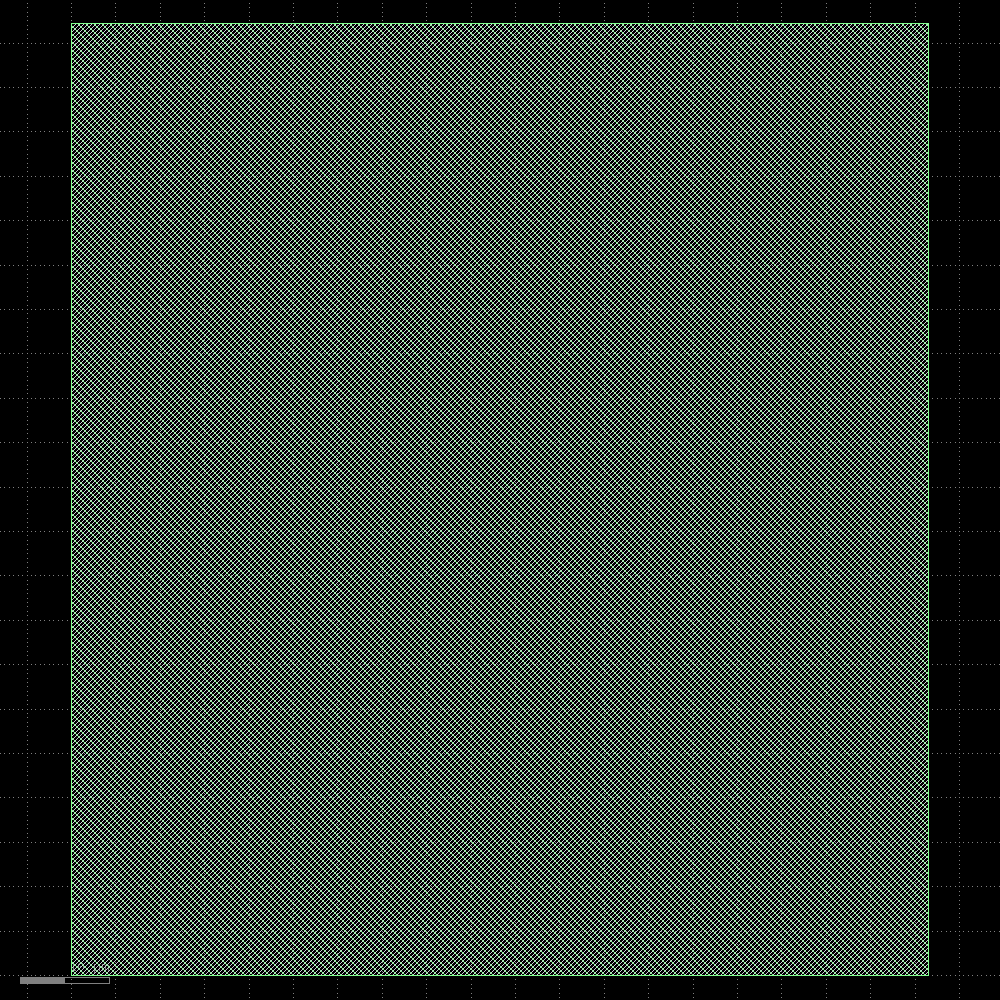

In [11]:
display(floorplan)

# Tap/Endcap Cell Insertion

In [12]:
TapEndcapInsertion = Step.factory.get("OpenROAD.TapEndcapInsertion")

tdi = TapEndcapInsertion(state_in=floorplan.state_out)
tdi.start()

─────────────────────────────────────────────── Tap/Decap Insertion ───────────────────────────────────────────────

[08:55:03] VERBOSE  Running 'OpenROAD.TapEndcapInsertion' at                                           ]8;id=506836;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=375253;file:///content/librelane_ipynb/librelane/steps/step.py#1140\1140]8;;\
                    'librelane_run/3-openroad-tapendcapinsertion'…                                                 

[08:55:03] VERBOSE  Logging subprocess to                                                              ]8;id=584498;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=544469;file:///content/librelane_ipynb/librelane/steps/step.py#1336\1336]8;;\
                    'librelane_run/3-openroad-tapendcapinsertion/openroad-tapendcapinsertion.log'…                 

Reading OpenROAD database at '/content/librelane_run/2-openroad-floorplan/spm.odb'…

Reading library file at '/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/3-openroad-tapendcapinsertion/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/3-openroad-tapendcapinsertion/spm.pnl.v'…

Writing layout to '/content/librelane_run/3-openroad-tapendcapinsertion/spm.def'…

Writing timing constraints to '/content/librelane_run/3-openroad-tapendcapinsertion/spm.sdc'…

Format,Path
nl,librelane_run/3-openroad-tapendcapinsertion/spm.nl.v
pnl,librelane_run/3-openroad-tapendcapinsertion/spm.pnl.v
def,librelane_run/3-openroad-tapendcapinsertion/spm.def
odb,librelane_run/3-openroad-tapendcapinsertion/spm.odb
sdc,librelane_run/3-openroad-tapendcapinsertion/spm.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[08:55:30] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_8xmmf_nr'…               ]8;id=647419;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=332097;file:///content/librelane_ipynb/librelane/steps/step.py#1140\1140]8;;\

[08:55:30] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_8xmmf_nr/klayout-render.log'…  ]8;id=637425;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=255147;file:///content/librelane_ipynb/librelane/steps/step.py#1336\1336]8;;\

#### Time Elapsed: 0.91s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
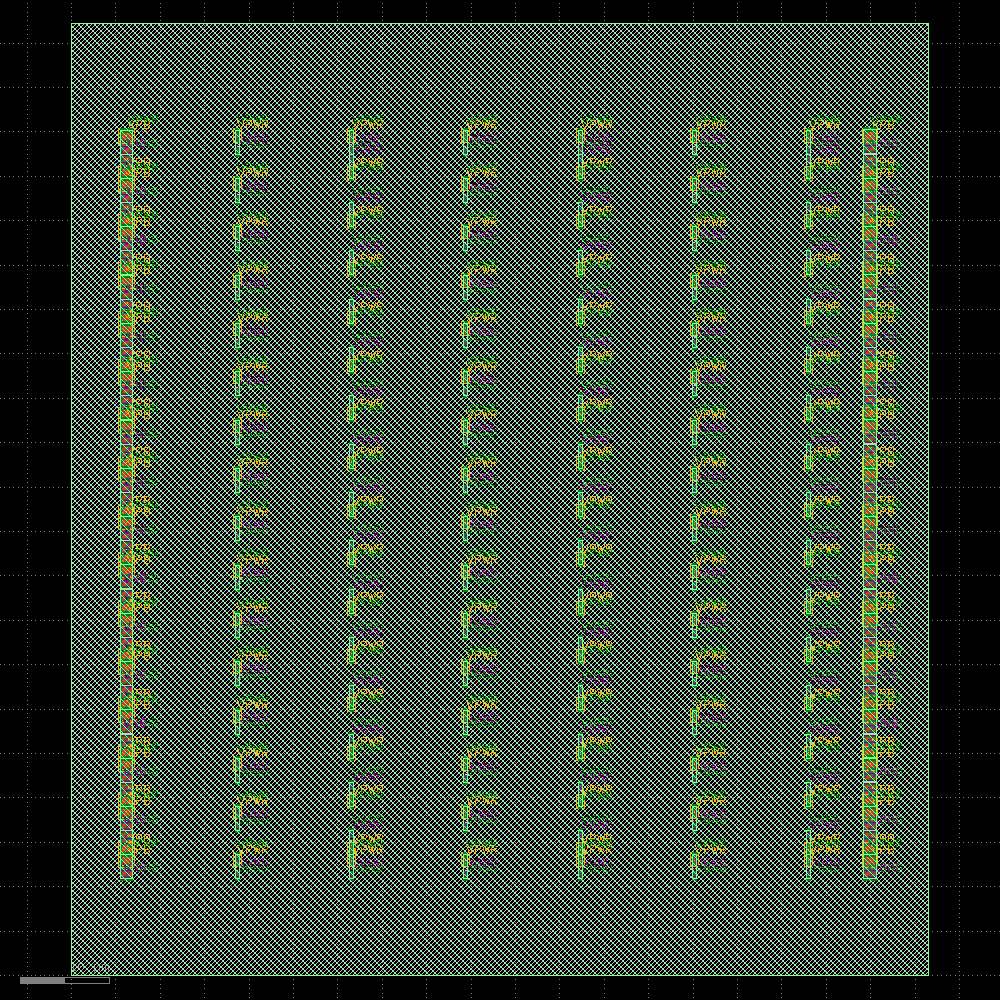

In [13]:
display(tdi)

# I/O Placement

In [14]:
IOPlacement = Step.factory.get("OpenROAD.IOPlacement")

ioplace = IOPlacement(state_in=tdi.state_out)
ioplace.start()

────────────────────────────────────────────────── I/O Placement ──────────────────────────────────────────────────

[08:57:50] VERBOSE  Running 'OpenROAD.IOPlacement' at 'librelane_run/4-openroad-ioplacement'…          ]8;id=523186;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=564407;file:///content/librelane_ipynb/librelane/steps/step.py#1140\1140]8;;\

[08:57:50] VERBOSE  Logging subprocess to                                                              ]8;id=25250;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=271070;file:///content/librelane_ipynb/librelane/steps/step.py#1336\1336]8;;\
                    'librelane_run/4-openroad-ioplacement/openroad-ioplacement.log'…                               

Reading OpenROAD database at '/content/librelane_run/3-openroad-tapendcapinsertion/spm.odb'…

Reading library file at '/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/4-openroad-ioplacement/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/4-openroad-ioplacement/spm.pnl.v'…

Writing layout to '/content/librelane_run/4-openroad-ioplacement/spm.def'…

Writing timing constraints to '/content/librelane_run/4-openroad-ioplacement/spm.sdc'…

Format,Path
nl,librelane_run/4-openroad-ioplacement/spm.nl.v
pnl,librelane_run/4-openroad-ioplacement/spm.pnl.v
def,librelane_run/4-openroad-ioplacement/spm.def
odb,librelane_run/4-openroad-ioplacement/spm.odb
sdc,librelane_run/4-openroad-ioplacement/spm.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[08:58:35] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_2rvnfj11'…               ]8;id=48395;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=892538;file:///content/librelane_ipynb/librelane/steps/step.py#1140\1140]8;;\

[08:58:35] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_2rvnfj11/klayout-render.log'…  ]8;id=668774;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=544939;file:///content/librelane_ipynb/librelane/steps/step.py#1336\1336]8;;\

#### Time Elapsed: 0.81s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
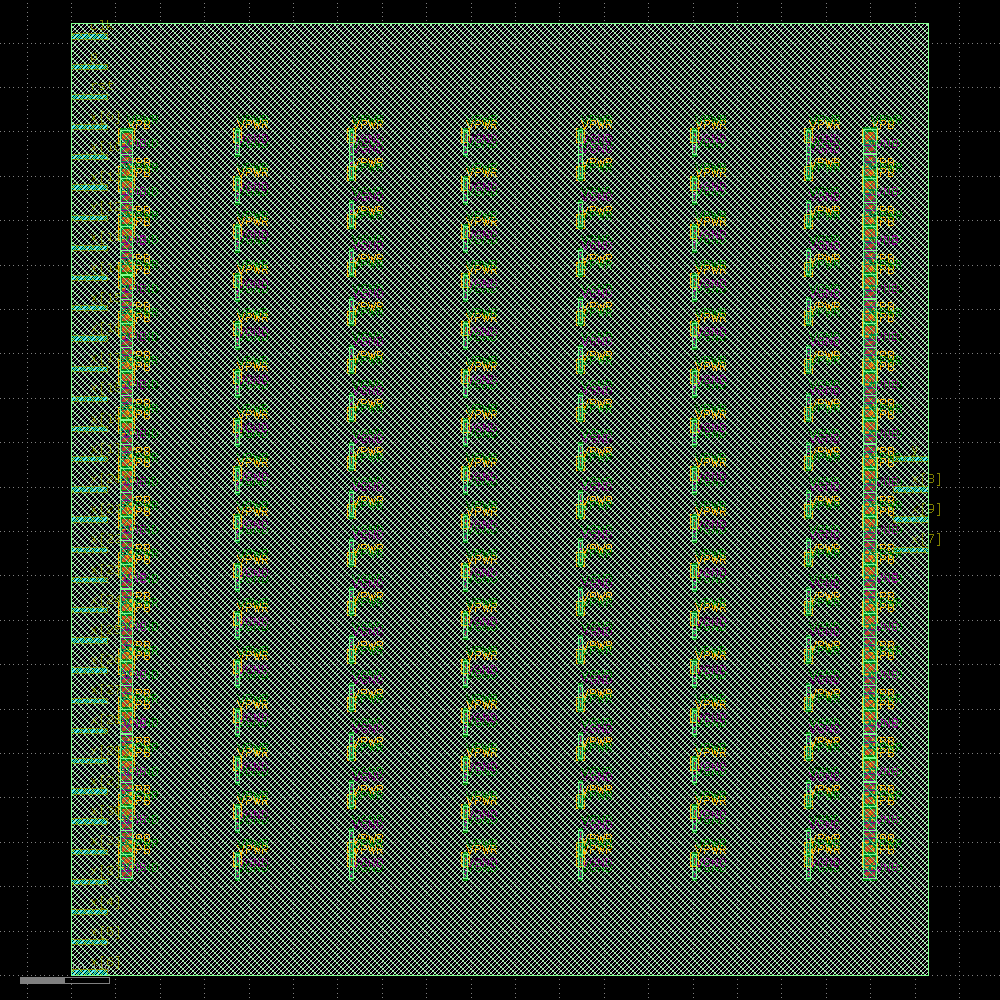

In [15]:
display(ioplace)

# Generating the Power Distribution Network (PDN)

In [16]:
GeneratePDN = Step.factory.get("OpenROAD.GeneratePDN")

pdn = GeneratePDN(
    state_in=ioplace.state_out,
    FP_PDN_VWIDTH=2,
    FP_PDN_HWIDTH=2,
    FP_PDN_VPITCH=30,
    FP_PDN_HPITCH=30,
)
pdn.start()

────────────────────────────────────── Power Distribution Network Generation ──────────────────────────────────────

[09:00:13] VERBOSE  Running 'OpenROAD.GeneratePDN' at 'librelane_run/5-openroad-generatepdn'…          ]8;id=812797;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=910692;file:///content/librelane_ipynb/librelane/steps/step.py#1140\1140]8;;\

[09:00:13] INFO     'FP_PDN_CFG' not explicitly set, setting it to                                 ]8;id=707437;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=251745;file:///content/librelane_ipynb/librelane/steps/openroad.py#1179\1179]8;;\
                    /content/librelane_ipynb/librelane/scripts/openroad/common/pdn_cfg.tcl…                        

[09:00:13] VERBOSE  Logging subprocess to                                                              ]8;id=524916;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=852456;file:///content/librelane_ipynb/librelane/steps/step.py#1336\1336]8;;\
                    'librelane_run/5-openroad-generatepdn/openroad-generatepdn.log'…                               

Reading OpenROAD database at '/content/librelane_run/4-openroad-ioplacement/spm.odb'…

...

Writing layout to '/content/librelane_run/5-openroad-generatepdn/spm.def'…

Writing timing constraints to '/content/librelane_run/5-openroad-generatepdn/spm.sdc'…

[INFO PSM-0040] All shapes on net VPWR are connected.

[INFO PSM-0040] All shapes on net VGND are connected.

Format,Path
nl,librelane_run/5-openroad-generatepdn/spm.nl.v
pnl,librelane_run/5-openroad-generatepdn/spm.pnl.v
def,librelane_run/5-openroad-generatepdn/spm.def
odb,librelane_run/5-openroad-generatepdn/spm.odb
sdc,librelane_run/5-openroad-generatepdn/spm.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[09:01:08] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_u29dezm8'…               ]8;id=286206;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=56477;file:///content/librelane_ipynb/librelane/steps/step.py#1140\1140]8;;\

[09:01:08] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_u29dezm8/klayout-render.log'…  ]8;id=668405;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=581621;file:///content/librelane_ipynb/librelane/steps/step.py#1336\1336]8;;\

#### Time Elapsed: 1.02s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
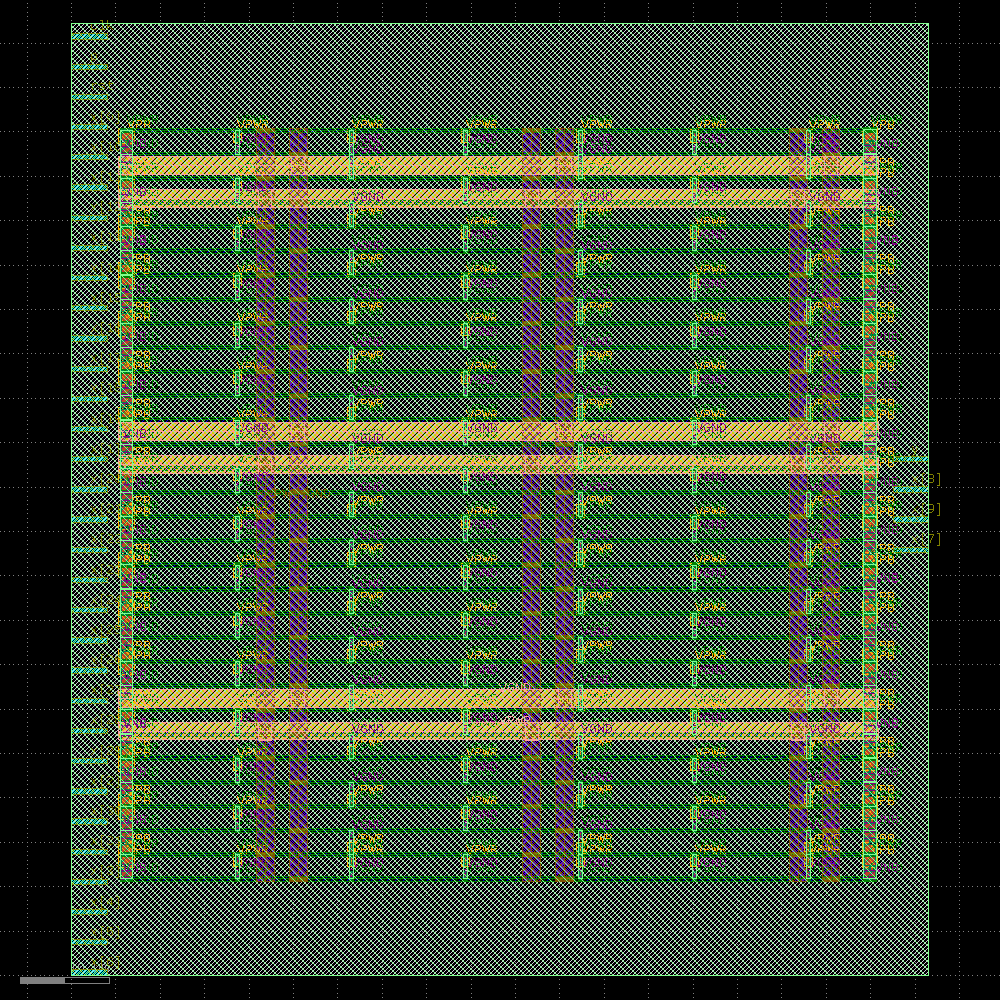

In [17]:
display(pdn)

# Global Placement

In [18]:
GlobalPlacement = Step.factory.get("OpenROAD.GlobalPlacement")

gpl = GlobalPlacement(state_in=pdn.state_out)
gpl.start()

──────────────────────────────────────────────── Global Placement ─────────────────────────────────────────────────

[09:02:17] VERBOSE  Running 'OpenROAD.GlobalPlacement' at 'librelane_run/6-openroad-globalplacement'…  ]8;id=236902;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=968191;file:///content/librelane_ipynb/librelane/steps/step.py#1140\1140]8;;\

[09:02:17] INFO     'PL_TARGET_DENSITY_PCT' not explicitly set, using dynamically calculated       ]8;id=837054;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=192866;file:///content/librelane_ipynb/librelane/steps/openroad.py#1265\1265]8;;\
                    target density: 62.659100…                                                                     

[09:02:17] VERBOSE  Logging subprocess to                                                              ]8;id=718609;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=144581;file:///content/librelane_ipynb/librelane/steps/step.py#1336\1336]8;;\
                    'librelane_run/6-openroad-globalplacement/openroad-globalplacement.log'…                       

Reading OpenROAD database at '/content/librelane_run/5-openroad-generatepdn/spm.odb'…

...

Writing netlist to '/content/librelane_run/6-openroad-globalplacement/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/6-openroad-globalplacement/spm.pnl.v'…

Writing layout to '/content/librelane_run/6-openroad-globalplacement/spm.def'…

Writing timing constraints to '/content/librelane_run/6-openroad-globalplacement/spm.sdc'…

Format,Path
nl,librelane_run/6-openroad-globalplacement/spm.nl.v
pnl,librelane_run/6-openroad-globalplacement/spm.pnl.v
def,librelane_run/6-openroad-globalplacement/spm.def
odb,librelane_run/6-openroad-globalplacement/spm.odb
sdc,librelane_run/6-openroad-globalplacement/spm.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[09:02:43] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_nc7_uaaz'…               ]8;id=769650;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=475817;file:///content/librelane_ipynb/librelane/steps/step.py#1140\1140]8;;\

[09:02:43] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_nc7_uaaz/klayout-render.log'…  ]8;id=258109;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=625176;file:///content/librelane_ipynb/librelane/steps/step.py#1336\1336]8;;\

#### Time Elapsed: 3.54s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
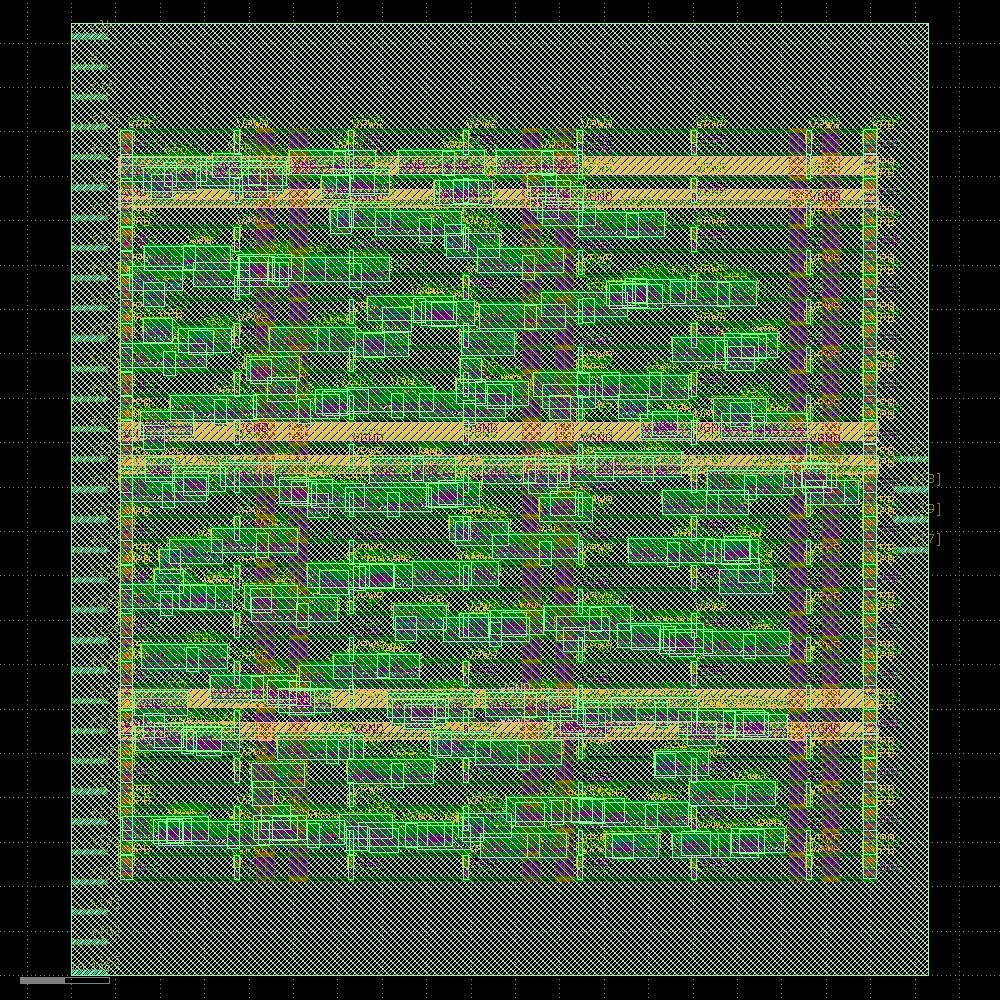

In [19]:
display(gpl)


# Detailed Placement

In [20]:
DetailedPlacement = Step.factory.get("OpenROAD.DetailedPlacement")

dpl = DetailedPlacement(state_in=gpl.state_out)
dpl.start()

─────────────────────────────────────────────── Detailed Placement ────────────────────────────────────────────────

[09:03:34] VERBOSE  Running 'OpenROAD.DetailedPlacement' at                                            ]8;id=806211;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=994567;file:///content/librelane_ipynb/librelane/steps/step.py#1140\1140]8;;\
                    'librelane_run/7-openroad-detailedplacement'…                                                  

[09:03:34] VERBOSE  Logging subprocess to                                                              ]8;id=269288;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=955270;file:///content/librelane_ipynb/librelane/steps/step.py#1336\1336]8;;\
                    'librelane_run/7-openroad-detailedplacement/openroad-detailedplacement.log'…                   

Reading OpenROAD database at '/content/librelane_run/6-openroad-globalplacement/spm.odb'…

Reading library file at '/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/7-openroad-detailedplacement/spm.nl.v'…

Writing powered netlist to '/content/librelane_run/7-openroad-detailedplacement/spm.pnl.v'…

Writing layout to '/content/librelane_run/7-openroad-detailedplacement/spm.def'…

Writing timing constraints to '/content/librelane_run/7-openroad-detailedplacement/spm.sdc'…

Format,Path
nl,librelane_run/7-openroad-detailedplacement/spm.nl.v
pnl,librelane_run/7-openroad-detailedplacement/spm.pnl.v
def,librelane_run/7-openroad-detailedplacement/spm.def
odb,librelane_run/7-openroad-detailedplacement/spm.odb
sdc,librelane_run/7-openroad-detailedplacement/spm.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[09:03:56] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_jpy3iae6'…               ]8;id=984917;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=371253;file:///content/librelane_ipynb/librelane/steps/step.py#1140\1140]8;;\

[09:03:56] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_jpy3iae6/klayout-render.log'…  ]8;id=848210;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=270232;file:///content/librelane_ipynb/librelane/steps/step.py#1336\1336]8;;\

#### Time Elapsed: 0.92s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
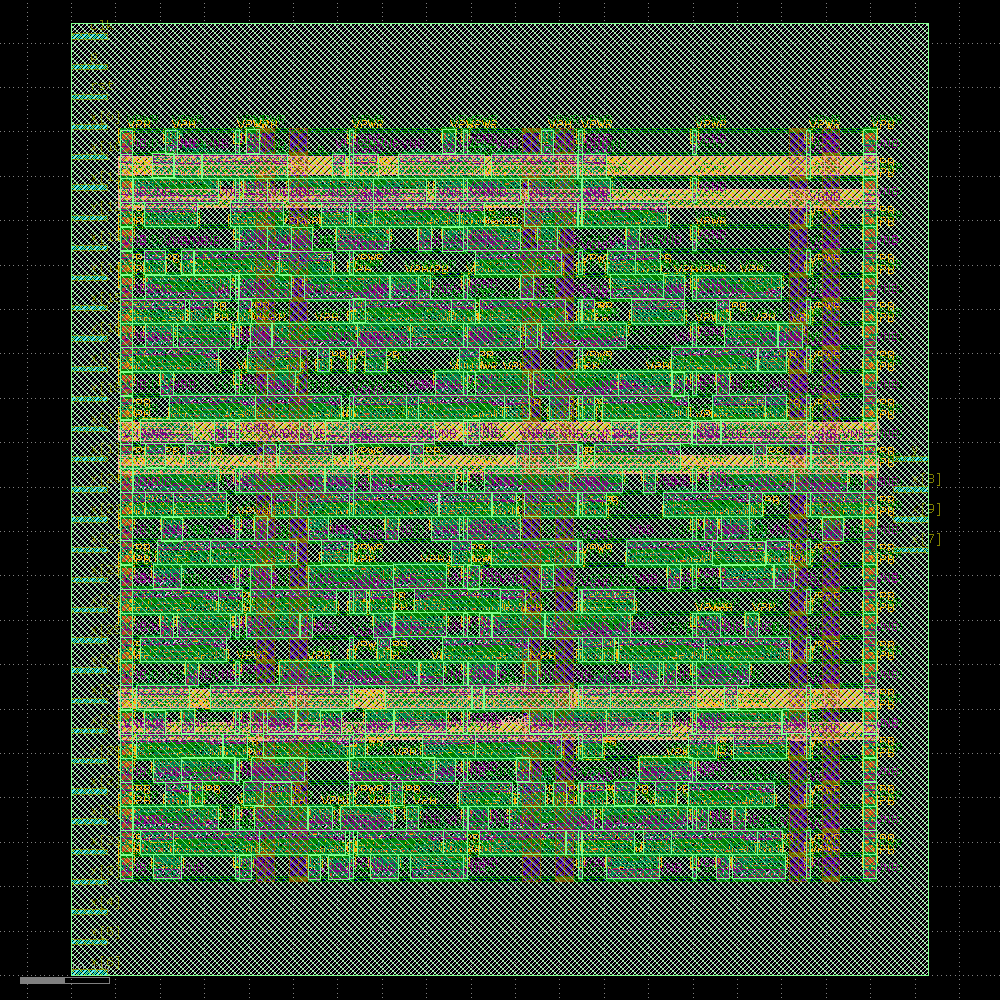

In [21]:
display(dpl)